<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>
<center><b><h2>Odedra Viraj - 23010101178 - 03/12/2025</b></center>

<center><b><h1>Lab - 2</b></center>    
<pre>    

# EDA & Pipeline: Google Play Store Apps

**Dataset:** Google Play Store Apps (Available on Kaggle) <BR>
**Objective:** Transform raw, messy data into clean, actionable insights using Pandas and Scikit-Learn pipelines.<BR>
**Focus:** Data Cleaning, String Sanitization, Advanced Imputation, Correlation, and Pipelines.<BR>

### 1. Setup & Initialization

**Exercise 1: Import Dependencies**
* Import `pandas`, `numpy`, `matplotlib.pyplot`, and `seaborn`.
* Set pandas options to display all columns (visual aid).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Exercise 2: Data Loading & Initial Inspection**
* Load the `googleplaystore.csv` file.
* Display the first 5 rows.
* **Check:** Look closely at the `Installs`, `Size`, and `Price` columns. Notice they are currently Objects (strings), not numbers.

In [7]:
data = pd.read_csv("googleplaystore.csv")
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### 2. Data Integrity Check

**Exercise 3: Audit Data Types and Missing Values**
* Use a single command to view data types (`dtypes`) and non-null counts.
* Calculate the *percentage* of missing values for each column.

In [10]:
# data.dtypes

In [11]:

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [12]:
( data.isnull().sum() / len(data) ) * 100 

App                0.000000
Category           0.000000
Rating            13.596532
Reviews            0.000000
Size               0.000000
Installs           0.000000
Type               0.009224
Price              0.000000
Content Rating     0.009224
Genres             0.000000
Last Updated       0.000000
Current Ver        0.073794
Android Ver        0.027673
dtype: float64

**Exercise 4: Handling Duplicates**
* Duplicate entries skew results. Check for duplicate rows.
* Drop duplicates, keeping the *first* occurrence. Verify the shape change.

In [14]:
# For Checking Duplicates use duplicated()
# Use drop_duplicates to Drop()

In [15]:
data[data.duplicated()]


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
236,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",Free,0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
239,Google My Business,BUSINESS,4.4,70991,Varies with device,"5,000,000+",Free,0,Everyone,Business,"July 24, 2018",2.19.0.204537701,4.4 and up
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37M,"10,000,000+",Free,0,Everyone,Business,"July 20, 2018",4.1.28165.0716,4.0 and up
261,join.me - Simple Meetings,BUSINESS,4.0,6989,Varies with device,"1,000,000+",Free,0,Everyone,Business,"July 16, 2018",4.3.0.508,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8643,Wunderlist: To-Do List & Tasks,PRODUCTIVITY,4.6,404610,Varies with device,"10,000,000+",Free,0,Everyone,Productivity,"April 6, 2018",Varies with device,Varies with device
8654,"TickTick: To Do List with Reminder, Day Planner",PRODUCTIVITY,4.6,25370,Varies with device,"1,000,000+",Free,0,Everyone,Productivity,"August 6, 2018",Varies with device,Varies with device
8658,ColorNote Notepad Notes,PRODUCTIVITY,4.6,2401017,Varies with device,"100,000,000+",Free,0,Everyone,Productivity,"June 27, 2018",Varies with device,Varies with device
10049,Airway Ex - Intubate. Anesthetize. Train.,MEDICAL,4.3,123,86M,"10,000+",Free,0,Everyone,Medical,"June 1, 2018",0.6.88,5.0 and up


In [16]:
print("Before :", data.duplicated().sum())


Before : 483


In [17]:
print("After : ", data.drop_duplicates().duplicated().sum())

After :  0


### 3. Advanced String Sanitization (Crucial Step)

**Exercise 5: Cleaning the 'Installs' Column**
* The `Installs` column contains characters like `+` and `,` (e.g., "10,000+").
* Remove these characters.
* Convert the column to a numeric integer type.

In [20]:
# use Column.astype(str).str.replace

data['Installs'] = data['Installs'].astype(str).str.replace('+', '').str.replace(',', '')



In [21]:
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [22]:
# data['Installs'] = data['Installs'].astype(int)

In [23]:
# use to_numeric to convert to int


data['Installs'] = pd.to_numeric(data['Installs'], errors = 'coerce')


In [24]:
data.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs          float64
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

**Exercise 6: Cleaning the 'Price' Column**
* The `Price` column contains the `$` symbol (e.g., "$4.99").
* Remove the symbol.
* Convert the column to a `float`.

In [26]:
data['Price'] = data['Price'].astype(str).str.replace('$', '');
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')

print(data['Price'].dtype)

float64


In [27]:
# Same as Above


**Exercise 7: Complex Logic - Sanitizing 'Size'**
* The `Size` column is messy. It contains 'M' (Megabytes), 'k' (kilobytes), and string 'Varies with device'.
* **Task:** Write a function (or apply lambda) to:
    1.  Replace 'k' with 'e+3' and 'M' with 'e+6'.
    2.  Coerce 'Varies with device' to `NaN`.
    3.  Convert the string to a number.

In [29]:
# Hint: Define a function clean_size(x).
# Hint: If 'M' in x: return float(x.replace('M', '')) * 1000000
# Hint: Handle the 'Varies with device' edge case carefully.

def clean_size(x):
    x = str(x)
    if 'M' in x:
        # Convert 19M to 19000000
       return float(x.replace('M', '')) * 1000000
        
    elif 'k' in x:
        # Convert 500k to 500000
        return float(x.replace('k', '')) * 1000
        
    elif 'Varies with device' in x:
        # Handle string edge case
        return np.nan
        
    else:
        # Attempt to convert or return NaN
        try:
            return float(x)
        except:
            return np.nan

# Use apply Method to apply above fun
data['Size'] = data['Size'].apply(clean_size)
print('Size column cleaned and converted.')



Size column cleaned and converted.


In [30]:
print(data['Size'].head())


0    19000000.0
1    14000000.0
2     8700000.0
3    25000000.0
4     2800000.0
Name: Size, dtype: float64


In [31]:
print(data['Size'].dtype)

float64


### 4. Advanced Imputation

**Exercise 8: Analyzing Missing 'Rating'**
* The `Rating` column has missing values.
* **Visualize** the distribution of Ratings using a Histogram or KDE plot to decide between Mean vs Median imputation.

<Axes: xlabel='Rating', ylabel='Count'>

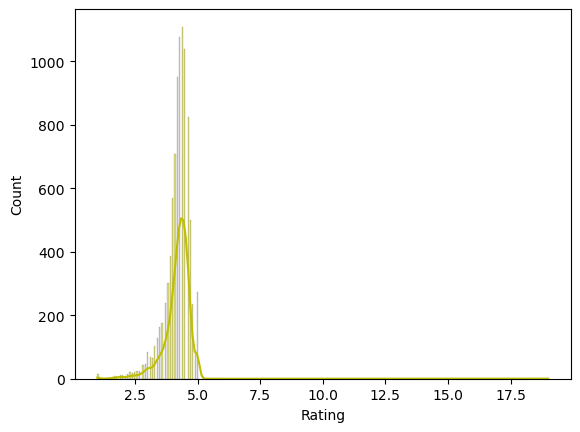

In [34]:
sns.histplot(data.Rating, kde = True, color = "y")



**Exercise 9: Group-Specific Imputation**
* Fill missing `Rating` values with the **Median Rating** of the specific `Category` the app belongs to.
* *Example:* If a "Business" app is missing a rating, fill it with the median rating of all "Business" apps.

In [36]:

#After this use transform Method

category_medians = data.groupby('Category')['Rating'].transform('median')

data['Rating'] = data['Rating'].fillna(category_medians)

print("Missing Rating After Imupatation :", data['Rating'].isnull().sum())

Missing Rating After Imupatation : 0


**Exercise 10: Drop Remaining NaNs**
* For the remaining columns with minimal missing data (like `Current Ver`), simply drop the rows containing NaNs to ensure a clean dataset for correlation.

In [38]:
# dropna
data.dropna(inplace=True)
print(data.isnull().sum())

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


In [102]:
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,-0.145110,-0.112204,-0.153897,Free,-0.06826,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,-0.144640,-0.333517,-0.143294,Free,-0.06826,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,-0.094237,-0.568109,-0.045925,Free,-0.06826,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,-0.019612,0.153372,0.927769,Free,-0.06826,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,-0.144640,-0.829258,-0.151949,Free,-0.06826,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [100]:
data.to_csv("googleplaystore_clean_data.csv", index = False)

### 5. Correlation & Visualization

**Exercise 11: Correlation Matrix**
* Generate a correlation matrix for the numerical columns (`Rating`, `Reviews`, `Size`, `Installs`, `Price`).

In [41]:

# Hint: numeric_only Use CORR

corr = data.corr(numeric_only = True)
corr




,Rating,Size,Installs,Price
Rating,1.000000,0.066508,0.046242,-0.018835
Size,0.066508,1.000000,0.164721,-0.023057
Installs,0.046242,0.164721,1.000000,-0.010489
Price,-0.018835,-0.023057,-0.010489,1.000000


**Exercise 12: Heatmap Visualization**
* Visualize the correlation matrix using a Seaborn Heatmap.
* Annotate the values.

<Axes: >

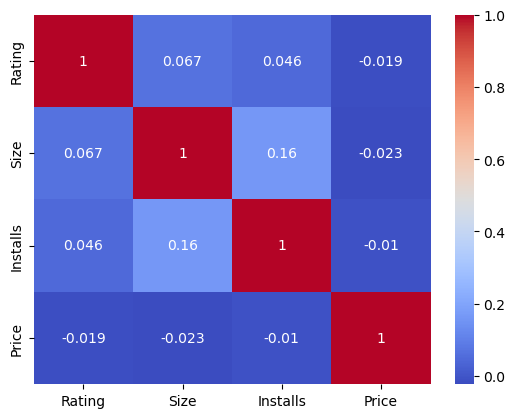

In [43]:
# Hint: sns.heatmap

sns.heatmap(corr, cmap = "coolwarm" ,annot = True)



**Exercise 13: Scatter Plot Analysis**
* Create a Scatter Plot to analyze the relationship between `Reviews` and `Installs`.
* **Note:** You might need to use a log scale for the axes if the data is skewed.

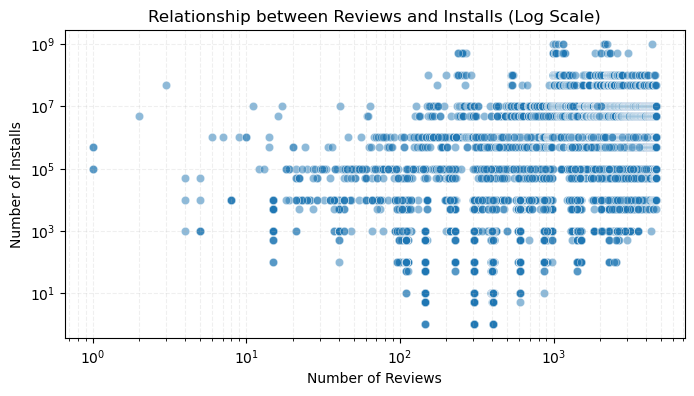

In [45]:
plt.figure(figsize=(8, 4))

sns.scatterplot(x='Reviews', y='Installs', data=data, alpha=0.5)

plt.xscale('log')
plt.yscale('log')

plt.title('Relationship between Reviews and Installs (Log Scale)')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Installs')
plt.grid(True, which="both", ls="--", alpha=0.2) 

plt.show()

In [46]:
# If needed
#plt.xscale('log')
#plt.yscale('log')
#plt.title('Reviews vs Installs (Log Scale)')
#plt.show()

**Exercise 14: Categorical Aggregation**
* Create a Bar Plot showing the top 10 Categories by **Total Installs**.

C:\Users\viraj\AppData\Local\Temp\ipykernel_16612\2908463684.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, palette='viridis')


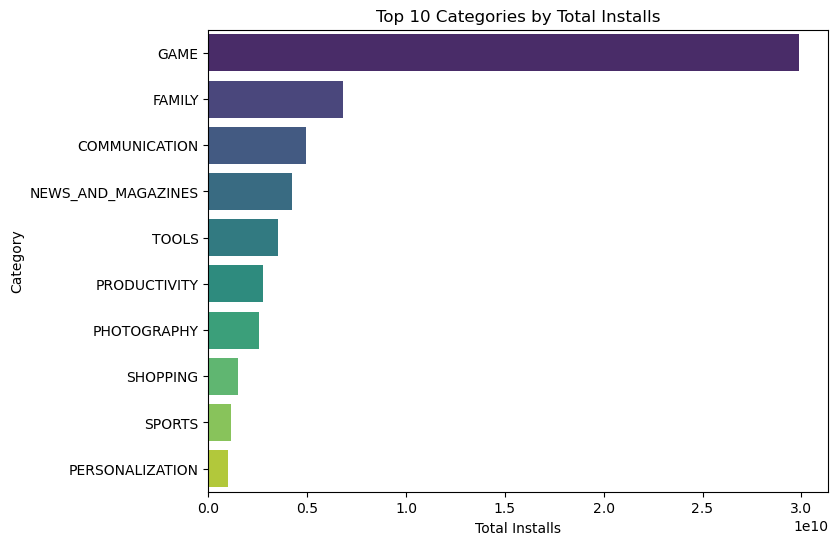

In [48]:

top_cats = data.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)


plt.figure(figsize=(8, 6))
sns.barplot(x=top_cats.values, y=top_cats.index, palette='viridis')

plt.title('Top 10 Categories by Total Installs')
plt.xlabel('Total Installs')
plt.ylabel('Category')
plt.show()


### 6. Building a Sklearn Pipeline

**Exercise 15: Preprocessing Pipeline**
* Imagine you want to predict the `Rating` (Target).
* Create a Scikit-Learn `ColumnTransformer` that:
    1.  StandardScales the numerical features (`Reviews`, `Size`, `Installs`, `Price`).
    2.  OneHotEncodes the categorical feature (`Category`, `Content Rating`).
* Display the pipeline object.

In [51]:
# 1. Import the necessary libraries
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define your feature groups
numeric_features = ['Reviews', 'Size', 'Installs', 'Price']
categorical_features = ['Category', 'Content Rating']

# 2. Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 3. Display the object to verify it works
print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Reviews', 'Size', 'Installs', 'Price']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Category', 'Content Rating'])])


# Without Pipline

In [53]:



# Use

from sklearn.preprocessing import StandardScaler

# 1. Identify the columns you want to scale
cols_to_scale = ['Reviews', 'Size', 'Installs', 'Price']

# 2. Initialize the Scaler
scaler = StandardScaler()

# 3. Fit and Transform
# 'fit' calculates the Mean and Std Dev
# 'transform' actually modifies the numbers
# We use fit_transform() to do both at once
scaled_values = scaler.fit_transform(data[cols_to_scale])

# 4. Assign the results back to the DataFrame
# (Scikit-Learn returns a NumPy array, so we must map it back to the columns)
data[cols_to_scale] = scaled_values

# Check the results - values should look small (e.g., -1.2, 0.5, 2.1)
print(data[cols_to_scale].head())

    Reviews      Size  Installs    Price
0 -0.145110 -0.112204 -0.153897 -0.06826
1 -0.144640 -0.333517 -0.143294 -0.06826
2 -0.094237 -0.568109 -0.045925 -0.06826
3 -0.019612  0.153372  0.927769 -0.06826
4 -0.144640 -0.829258 -0.151949 -0.06826


# With Pipline(Optional part)

In [55]:

# Hint: from sklearn.compose import ColumnTransformer
# Hint: from sklearn.preprocessing import StandardScaler, OneHotEncoder
# Hint: from sklearn.pipeline import Pipeline


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# 1. Define your feature groups
numeric_features = ['Reviews', 'Size', 'Installs', 'Price']
categorical_features = ['Category', 'Content Rating']

# 2. Define the Preprocessor (The ColumnTransformer)
# This splits the data: Numeric cols go to StandardScaler, Categorical cols go to OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 3. Create the Pipeline
# We wrap the preprocessor in a Pipeline. 
# (In the future, you can add a model like 'regressor' as a second step here)
my_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# 4. Run it on your data
# This returns a processed NumPy array (or sparse matrix) ready for AI models
processed_data = my_pipeline.fit_transform(data)

print("Pipeline constructed and applied successfully.")
print(f"Shape of processed data: {processed_data.shape}")

Pipeline constructed and applied successfully.
Shape of processed data: (9135, 43)
